In [11]:
# ── Cell 1: imports & setup ───────────────────────────────────────────────
%pip install matplotlib
%pip install geopandas
%pip install contextily
%pip install mapclassify
import requests
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Point
 
# Download Natural Earth countries (GeoPandas 1.0+ compatible)
world_url = "https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip"
world = gpd.read_file(world_url)
world = world.rename(columns={"NAME": "name"})[["name", "geometry"]]
print(f"World dataset loaded: {len(world)} countries")

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 14.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.1/12.1 MB 24.0 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 39.4/39.4 MB 27.7 MB/s  0:00:01m0:00:0100:01
  Attempting uninstall: scipy
    Found existing installation: scipy 1.6.3
    Uninstalling scipy-1.6.3:m━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1/5 [scipy]
      Successfully uninstalled scipy-1.6.3━━━━━━━━━━━━━━━━━━━━ 1/5 [scipy]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [mapclassify] [mapclassify]]
Note: you may need to restart the kernel to use updated packages.
World dataset loaded: 177 countries


In [12]:
# ── Cell 2: fetch USGS data ───────────────────────────────────────────────────
URL = (
    "https://earthquake.usgs.gov/fdsnws/event/1/query"
    "?format=geojson&minmagnitude=2.5&orderby=time&limit=2000"
    "&starttime=2025-04-01&endtime=2025-05-01"
)
response = requests.get(URL)
data = response.json()
print(f"Events fetched: {len(data['features'])}")

Events fetched: 2000


In [13]:
# ── Cell 3: parse into GeoDataFrame ──────────────────────────────────────────
rows = []
for feature in data["features"]:
    props = feature["properties"]
    coords = feature["geometry"]["coordinates"]  # [lon, lat, depth]
    rows.append({
        "magnitude": props["mag"],
        "place":     props["place"],
        "depth_km":  coords[2],
        "geometry":  Point(coords[0], coords[1]),
    })
 
gdf = gpd.GeoDataFrame(rows, crs="EPSG:4326")
print(gdf.head())
print(f"\nMagnitude range: {gdf['magnitude'].min():.1f} – {gdf['magnitude'].max():.1f}")
print(f"Depth range:     {gdf['depth_km'].min():.1f} – {gdf['depth_km'].max():.1f} km")

   magnitude                             place  depth_km  \
0        4.9     288 km N of Tobelo, Indonesia    17.647   
1        2.9  73 km E of Port Alsworth, Alaska   123.600   
2        4.1        17 km SE of Bodrum, Turkey    18.669   
3        4.5     276 km N of Tobelo, Indonesia    10.000   
4        4.8     283 km N of Tobelo, Indonesia    19.533   

                    geometry  
0    POINT (128.2079 4.3327)  
1  POINT (-153.0059 60.1426)  
2    POINT (27.5577 36.9176)  
3    POINT (128.3395 4.2045)  
4    POINT (128.3407 4.2718)  

Magnitude range: 2.5 – 6.9
Depth range:     -2.2 – 642.9 km


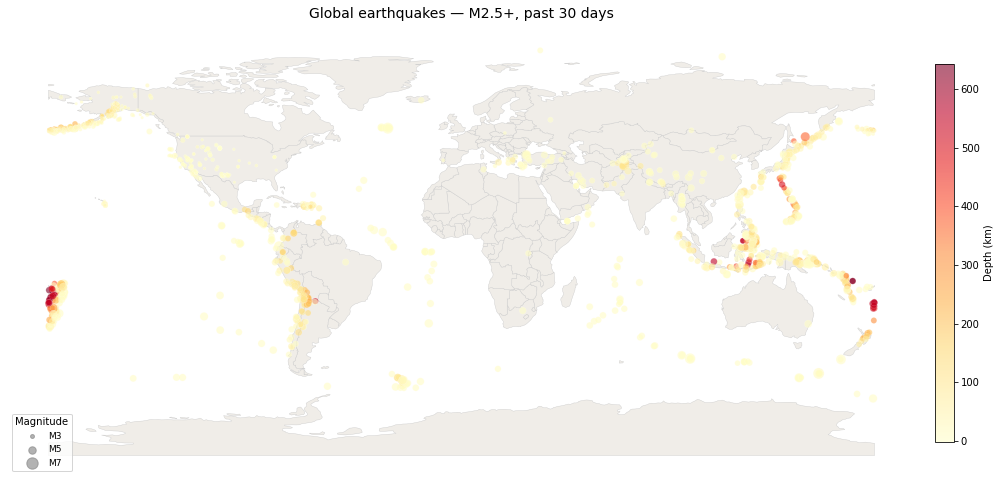

In [14]:
# ── Cell 4: scatter map — points sized by magnitude, coloured by depth ────────
fig, ax = plt.subplots(figsize=(14, 7))
 
world.plot(ax=ax, color="#f0ede8", edgecolor="#ccc", linewidth=0.4)
 
sc = ax.scatter(
    gdf.geometry.x,
    gdf.geometry.y,
    c=gdf["depth_km"],
    s=gdf["magnitude"] ** 2.5,
    cmap="YlOrRd",
    alpha=0.6,
    linewidths=0.2,
    edgecolors="white",
    zorder=3,
)
 
cbar = plt.colorbar(sc, ax=ax, fraction=0.02, pad=0.02)
cbar.set_label("Depth (km)", fontsize=10)
 
for mag, label in [(3, "M3"), (5, "M5"), (7, "M7")]:
    ax.scatter([], [], s=mag**2.5, c="gray", alpha=0.6, label=label)
ax.legend(title="Magnitude", loc="lower left", fontsize=9)
 
ax.set_title("Global earthquakes — M2.5+, past 30 days", fontsize=14, pad=12)
ax.set_axis_off()
plt.tight_layout()
plt.savefig("eq_scatter.png", dpi=150, bbox_inches="tight")
plt.show()

In [15]:
# ── Cell 5: spatial join — count events per country ──────────────────────────
joined = gpd.sjoin(gdf, world, how="left", predicate="within")
 
country_stats = (
    joined.groupby("name")
    .agg(event_count=("magnitude", "count"), mean_mag=("magnitude", "mean"))
    .reset_index()
)
 
world_stats = world.merge(country_stats, on="name", how="left")
world_stats["event_count"] = world_stats["event_count"].fillna(0)
 
print(country_stats.sort_values("event_count", ascending=False).head(10))

                        name  event_count  mean_mag
41  United States of America          257  2.880233
7                      Chile           34  4.255882
34               Puerto Rico           28  2.835000
8                      China           24  4.437500
17                 Indonesia           20  4.365000
24                   Myanmar           20  4.305000
38                Tajikistan           16  4.343750
1                  Argentina           16  4.225000
30                      Peru           15  4.493333
29          Papua New Guinea           14  4.557143


/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/mapclassify/classifiers.py:1653: UserWarning: Not enough unique values in array to form 5 classes. Setting k to 3.
  self.bins = quantile(y, k=k)


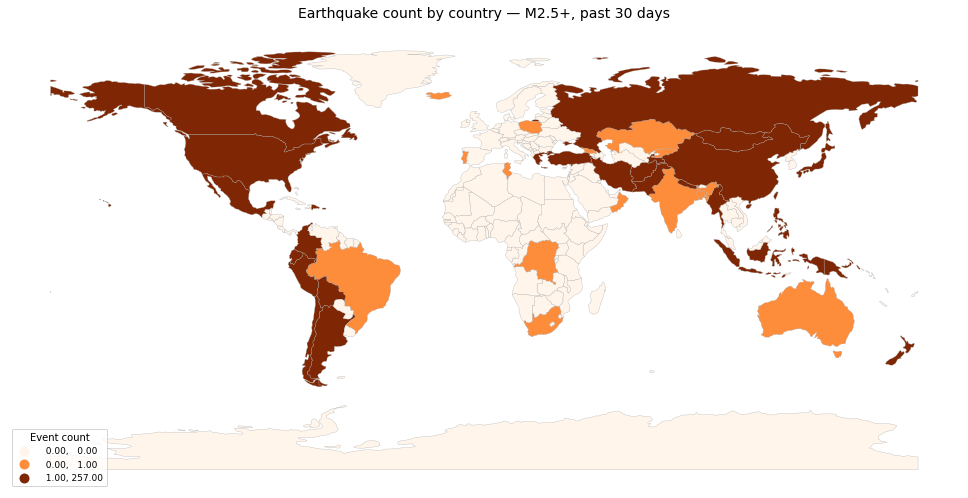

In [16]:
# ── Cell 6: choropleth — earthquake count per country ────────────────────────
fig, ax = plt.subplots(figsize=(14, 7))
 
world_stats.plot(
    column="event_count",
    ax=ax,
    cmap="Oranges",
    scheme="quantiles",
    k=5,
    legend=True,
    legend_kwds={"title": "Event count", "loc": "lower left", "fontsize": 9},
    edgecolor="#aaa",
    linewidth=0.3,
    missing_kwds={"color": "#eeeeee", "label": "No data"},
)
 
ax.set_title("Earthquake count by country — M2.5+, past 30 days", fontsize=14, pad=12)
ax.set_axis_off()
plt.tight_layout()
plt.savefig("eq_choropleth.png", dpi=150, bbox_inches="tight")
plt.show()

/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/mapclassify/classifiers.py:1653: UserWarning: Not enough unique values in array to form 5 classes. Setting k to 3.
  self.bins = quantile(y, k=k)


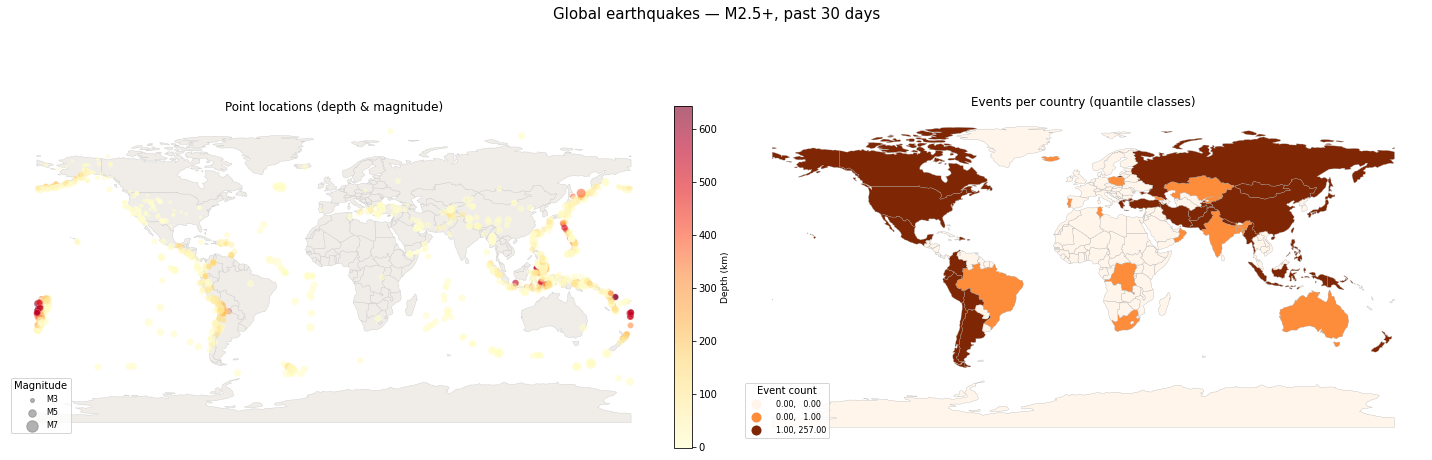

In [17]:
# ── Cell 7: multi-panel figure ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(20, 7))
 
# Left — scatter
world.plot(ax=axes[0], color="#f0ede8", edgecolor="#ccc", linewidth=0.4)
sc = axes[0].scatter(
    gdf.geometry.x, gdf.geometry.y,
    c=gdf["depth_km"], s=gdf["magnitude"] ** 2.5,
    cmap="YlOrRd", alpha=0.6, linewidths=0.2, edgecolors="white", zorder=3,
)
plt.colorbar(sc, ax=axes[0], fraction=0.025, pad=0.02).set_label("Depth (km)", fontsize=9)
for mag, label in [(3, "M3"), (5, "M5"), (7, "M7")]:
    axes[0].scatter([], [], s=mag**2.5, c="gray", alpha=0.6, label=label)
axes[0].legend(title="Magnitude", loc="lower left", fontsize=8)
axes[0].set_title("Point locations (depth & magnitude)", fontsize=12)
axes[0].set_axis_off()
 
# Right — choropleth
world_stats.plot(
    column="event_count", ax=axes[1], cmap="Oranges",
    scheme="quantiles", k=5, legend=True,
    legend_kwds={"title": "Event count", "loc": "lower left", "fontsize": 8},
    edgecolor="#aaa", linewidth=0.3,
    missing_kwds={"color": "#eeeeee"},
)
axes[1].set_title("Events per country (quantile classes)", fontsize=12)
axes[1].set_axis_off()
 
fig.suptitle("Global earthquakes — M2.5+, past 30 days", fontsize=15, y=1.01)
plt.tight_layout()
plt.savefig("eq_multipanel.png", dpi=150, bbox_inches="tight")
plt.show()